# Fase 2 — Otimização via Algoritmo Genético + Interpretação com LLM
## Câncer de mama: Regressão Linear, Regressão Logística e Random Forest

Este notebook usa as funções de `src/ga_utils.py` (Algoritmo Genético) e `src/llm_utils.py` (integração com o Claude) para:

1. Otimizar os hiperparâmetros dos 3 modelos já treinados na fase 1.
2. Rodar 5 experimentos: 3 com configurações diferentes do GA, um por algoritmo (Experimentos 1–3), e mais 2 trocando o algoritmo de seleção e de mutação, pra isolar o efeito de cada operador (Experimentos 4–5).
3. Comparação de cada modelo original com sua versão otimizada.
4. Depois do treino, ler as **feature importances** do melhor modelo e exportar as 10 medidas que mais pesaram (`experiments/results/feature_importances.json`).
5. Para integração com LLM utilizamos o modelo **claude-haiku-4-5**.

O loop de gerações do algoritmo genético está na função `ga_utils.rodar_ga` que é chamada por cada experimento só mudando os parâmetros.

## Deciõses

*Por que recall pesa mais na fitness?* Em diagnóstico de câncer, classificar um tumor **maligno como benigno** (falso negativo) é o erro mais grave clinicamente.

*Por que seleção por torneio?* É simples de implementar e funciona bem mesmo quando os fitness estão próximos entre si — sorteia `k` indivíduos, o 

*Por que crossover uniforme?* Os hiperparâmetros não têm uma ordem natural entre si, então decidir gene a gene (independentemente) de qual pai herdar faz mais sentido do que cortar o dict num ponto fixo.

In [1]:
import sys
import json
import random
from pathlib import Path

SRC_DIR = Path.cwd().parent / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ga_utils
import llm_utils

X_train, X_test, y_train, y_test, feature_names, scaler = ga_utils.carregar_dados()
print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")

RESULTADOS_DIR = Path("..") / "experiments" / "results"
RESULTADOS_DIR.mkdir(parents=True, exist_ok=True)

Matplotlib is building the font cache; this may take a moment.


Treino: (455, 30) | Teste: (114, 30)


## Baseline (Fase 1) — modelos originais

Métricas obtidas na fase 1, no mesmo holdout de teste (20%, `random_state=42`):

| Modelo | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Regressão Linear (limiar 0,5) | 0.9649 | 1.0000 | 0.9048 | 0.9500 |
| Regressão Logística | 0.9649 | 0.9750 | 0.9286 | 0.9512 |
| Random Forest | 0.9737 | 1.0000 | 0.9286 | 0.9630 |

Vamos rodar o GA para tentar melhorar cada um desses três — um experimento por algoritmo, cada um com uma configuração diferente do GA.

## Experimento 1 — GA na Regressão Logística

**Configuração deste experimento**: população maior (20), mutação alta (30%), 10 gerações.

Geração 0: melhor=0.9622  média=0.9543  mutação=0.200
Geração 1: melhor=0.9622  média=0.9561  mutação=0.200
Geração 2: melhor=0.9622  média=0.9568  mutação=0.200
Geração 3: melhor=0.9622  média=0.9590  mutação=0.200
Geração 4: melhor=0.9635  média=0.9597  mutação=0.200
Geração 5: melhor=0.9635  média=0.9611  mutação=0.200
Geração 6: melhor=0.9678  média=0.9606  mutação=0.200
Geração 7: melhor=0.9678  média=0.9608  mutação=0.200
Geração 8: melhor=0.9678  média=0.9636  mutação=0.200
Geração 9: melhor=0.9678  média=0.9638  mutação=0.200
Geração 10: melhor=0.9734  média=0.9629  mutação=0.200
Geração 11: melhor=0.9734  média=0.9649  mutação=0.200
Geração 12: melhor=0.9734  média=0.9640  mutação=0.200
Geração 13: melhor=0.9734  média=0.9669  mutação=0.200
Geração 14: melhor=0.9734  média=0.9660  mutação=0.200

Melhores hiperparâmetros encontrados: {'C': 0.21835702465724063, 'penalty': 'l2', 'class_weight': 'balanced'}


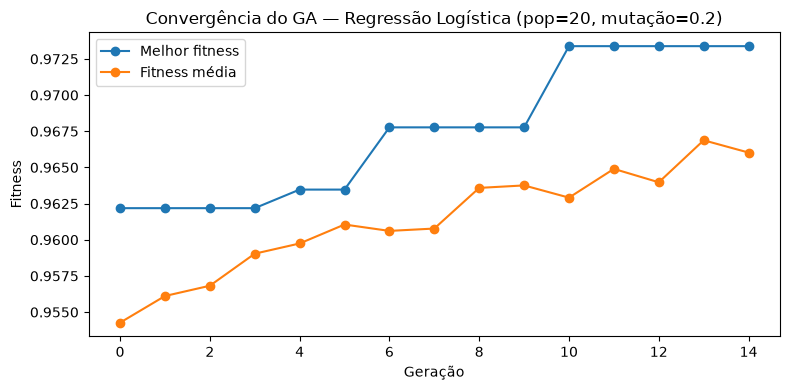

,accuracy,precision,recall,f1
Original,0.973684,0.97561,0.952381,0.963855
Otimizado (GA),0.982456,0.97619,0.976190,0.976190


In [2]:
populacao_rlog=20
geracoes_rlog=15
mutacao_rlog=0.2
populacao, historico_log, fitnesses, melhor_log = ga_utils.rodar_ga(
    "regressao_logistica", X_train, y_train, X_test, y_test,
    tamanho_populacao=populacao_rlog, geracoes=geracoes_rlog, mutacao=mutacao_rlog, seed=42,
)
print("\nMelhores hiperparâmetros encontrados:", melhor_log)

pd.DataFrame(historico_log).to_csv(RESULTADOS_DIR / "fitness_history_regressao_logistica.csv", index=False)
with open(RESULTADOS_DIR / "best_hyperparams_regressao_logistica.json", "w") as f:
    json.dump({"algoritmo": "regressao_logistica", "melhor_individuo": melhor_log}, f, indent=2, default=str)

plt.figure(figsize=(8, 4))
plt.plot([h["geracao"] for h in historico_log], [h["melhor"] for h in historico_log], label="Melhor fitness", marker="o")
plt.plot([h["geracao"] for h in historico_log], [h["media"] for h in historico_log], label="Fitness média", marker="o")
plt.xlabel("Geração"); plt.ylabel("Fitness"); plt.title(f"Convergência do GA — Regressão Logística (pop={populacao_rlog}, mutação={mutacao_rlog})")
plt.legend(); plt.tight_layout(); plt.show()

modelo_log_original = ga_utils.construir_log(ga_utils.LOG_BASELINE)
modelo_log_original.fit(X_train, y_train)
y_pred_original = modelo_log_original.predict(X_test)
metricas_log_original = ga_utils.calcular_metricas(y_test, y_pred_original)

modelo_log_otimizado = ga_utils.construir_log(melhor_log)
modelo_log_otimizado.fit(X_train, y_train)
y_pred_otimizado = modelo_log_otimizado.predict(X_test)
metricas_log_otimizado = ga_utils.calcular_metricas(y_test, y_pred_otimizado)

pd.DataFrame([metricas_log_original, metricas_log_otimizado], index=["Original", "Otimizado (GA)"])

## Experimento 2 — GA na Regressão Logística com mutação adaptativa

*Por que trocar a mutação?* O Experimento 2 usa uma taxa de mutação fixa (20%) durante todas as gerações. Aqui isolamos o efeito de trocar só a mutação, mantendo seleção por torneio e o resto igual ao Experimento 2: a taxa começa em 20% (mesmo valor do Experimento 2) e **decai linearmente até 5%** na última geração — mais exploração no início da busca, mais ajuste fino no final.

**Configuração**: igual ao Experimento 2 (pop=20, 15 gerações), com `mutacao=0.2, mutacao_final=0.05`.

Geração 0: melhor=0.9622  média=0.9543  mutação=0.200
Geração 1: melhor=0.9622  média=0.9561  mutação=0.189
Geração 2: melhor=0.9622  média=0.9567  mutação=0.179
Geração 3: melhor=0.9622  média=0.9591  mutação=0.168
Geração 4: melhor=0.9635  média=0.9611  mutação=0.157
Geração 5: melhor=0.9635  média=0.9611  mutação=0.146
Geração 6: melhor=0.9678  média=0.9630  mutação=0.136
Geração 7: melhor=0.9678  média=0.9645  mutação=0.125
Geração 8: melhor=0.9678  média=0.9627  mutação=0.114
Geração 9: melhor=0.9678  média=0.9661  mutação=0.104
Geração 10: melhor=0.9678  média=0.9654  mutação=0.093
Geração 11: melhor=0.9678  média=0.9669  mutação=0.082
Geração 12: melhor=0.9678  média=0.9671  mutação=0.071
Geração 13: melhor=0.9678  média=0.9660  mutação=0.061
Geração 14: melhor=0.9678  média=0.9671  mutação=0.050

Melhores hiperparâmetros encontrados: {'C': 0.3199896888183141, 'penalty': 'l1', 'class_weight': 'balanced'}


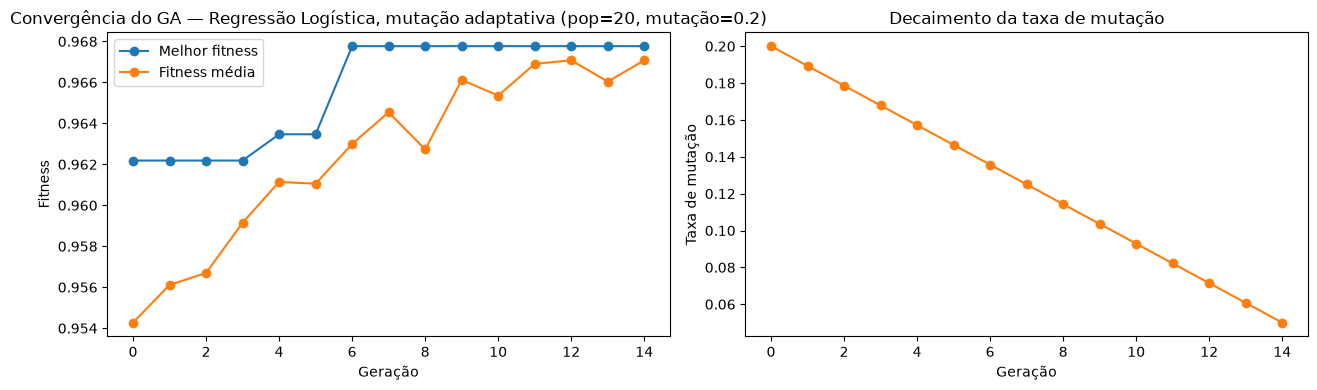

,accuracy,precision,recall,f1
Original,0.973684,0.97561,0.952381,0.963855
Experimento 2 (mutação fixa),0.982456,0.97619,0.976190,0.976190
Experimento 5 (mutação adaptativa),0.973684,0.97561,0.952381,0.963855


In [3]:
populacao_rlog2=20
geracoes_rlog2=15
mutacao_rlog2=0.2
populacao, historico_log_adaptativo, fitnesses, melhor_log_adaptativo = ga_utils.rodar_ga(
    "regressao_logistica", X_train, y_train, X_test, y_test,
    tamanho_populacao=populacao_rlog2, geracoes=geracoes_rlog2, mutacao=mutacao_rlog2, mutacao_final=0.05, seed=42,
)
print("\nMelhores hiperparâmetros encontrados:", melhor_log_adaptativo)

pd.DataFrame(historico_log_adaptativo).to_csv(RESULTADOS_DIR / "fitness_history_regressao_logistica_mutacao_adaptativa.csv", index=False)
with open(RESULTADOS_DIR / "best_hyperparams_regressao_logistica_mutacao_adaptativa.json", "w") as f:
    json.dump({"algoritmo": "regressao_logistica", "melhor_individuo": melhor_log_adaptativo}, f, indent=2, default=str)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot([h["geracao"] for h in historico_log_adaptativo], [h["melhor"] for h in historico_log_adaptativo], label="Melhor fitness", marker="o")
ax1.plot([h["geracao"] for h in historico_log_adaptativo], [h["media"] for h in historico_log_adaptativo], label="Fitness média", marker="o")
ax1.set_xlabel("Geração"); ax1.set_ylabel("Fitness"); ax1.set_title(f"Convergência do GA — Regressão Logística, mutação adaptativa (pop={populacao_rlog2}, mutação={mutacao_rlog2})")
ax1.legend()

ax2.plot([h["geracao"] for h in historico_log_adaptativo], [h["taxa_mutacao"] for h in historico_log_adaptativo], marker="o", color="tab:orange")
ax2.set_xlabel("Geração"); ax2.set_ylabel("Taxa de mutação"); ax2.set_title("Decaimento da taxa de mutação")

plt.tight_layout(); plt.show()

modelo_log_adaptativo = ga_utils.construir_log(melhor_log_adaptativo)
modelo_log_adaptativo.fit(X_train, y_train)
y_pred_log_adaptativo = modelo_log_adaptativo.predict(X_test)
metricas_log_adaptativo = ga_utils.calcular_metricas(y_test, y_pred_log_adaptativo)

pd.DataFrame(
    [metricas_log_original, metricas_log_otimizado, metricas_log_adaptativo],
    index=["Original", "Experimento 2 (mutação fixa)", "Experimento 5 (mutação adaptativa)"],
)

## Experimento 3 — GA na Regressão Logística com mutação adaptativa e seleção por roleta

*Por que trocar a a seleção?* 
**Configuração**: igual ao Experimento 2 (pop=20, 15 gerações), com `mutacao=0.2, mutacao_final=0.05`.

Geração 0: melhor=0.9622  média=0.9543  mutação=0.200
Geração 1: melhor=0.9622  média=0.9556  mutação=0.189
Geração 2: melhor=0.9622  média=0.9580  mutação=0.179
Geração 3: melhor=0.9622  média=0.9587  mutação=0.168
Geração 4: melhor=0.9622  média=0.9612  mutação=0.157
Geração 5: melhor=0.9635  média=0.9608  mutação=0.146
Geração 6: melhor=0.9635  média=0.9616  mutação=0.136
Geração 7: melhor=0.9635  média=0.9614  mutação=0.125
Geração 8: melhor=0.9635  média=0.9615  mutação=0.114
Geração 9: melhor=0.9635  média=0.9610  mutação=0.104
Geração 10: melhor=0.9635  média=0.9611  mutação=0.093
Geração 11: melhor=0.9635  média=0.9626  mutação=0.082
Geração 12: melhor=0.9635  média=0.9626  mutação=0.071
Geração 13: melhor=0.9635  média=0.9625  mutação=0.061
Geração 14: melhor=0.9635  média=0.9630  mutação=0.050

Melhores hiperparâmetros encontrados: {'C': 0.48069259049309837, 'penalty': 'l1', 'class_weight': 'balanced'}


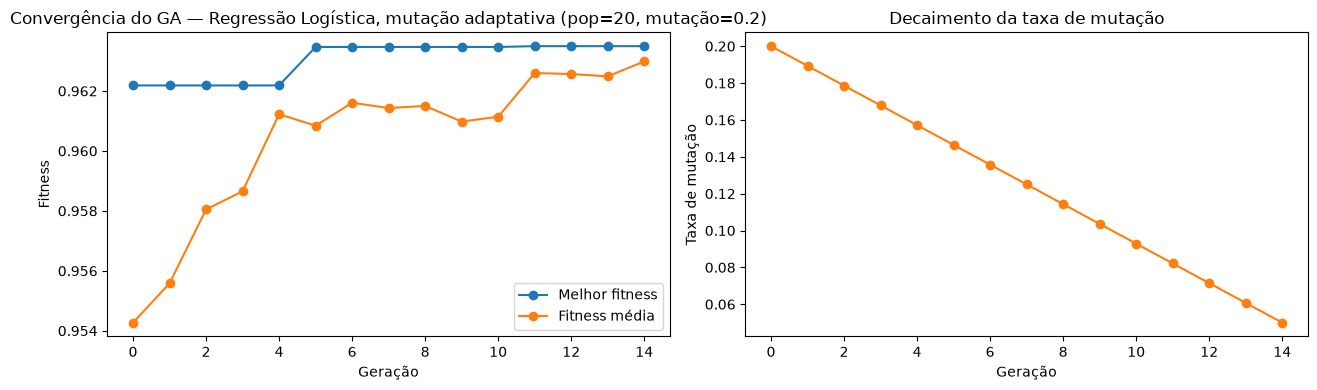

,accuracy,precision,recall,f1
Original,0.973684,0.97561,0.952381,0.963855
Experimento 2 (mutação fixa),0.982456,0.97619,0.976190,0.976190
Experimento 5 (mutação adaptativa),0.973684,0.97561,0.952381,0.963855
Experimento 6 (mutação adaptativa + seleção por roleta),0.973684,0.97561,0.952381,0.963855


In [4]:
populacao_rlog3=20
geracoes_rlog3=15
mutacao_rlog3=0.2
populacao, historico_log_adaptativo_roleta, fitnesses, melhor_log_adaptativo_roleta = ga_utils.rodar_ga(
    "regressao_logistica", X_train, y_train, X_test, y_test,
    tamanho_populacao=populacao_rlog3, geracoes=geracoes_rlog3, mutacao=mutacao_rlog3, selecao_func=ga_utils.selecao_roleta, mutacao_final=0.05, seed=42,
)
print("\nMelhores hiperparâmetros encontrados:", melhor_log_adaptativo_roleta)

pd.DataFrame(historico_log_adaptativo_roleta).to_csv(RESULTADOS_DIR / "fitness_history_regressao_logistica_mutacao_adaptativa.csv", index=False)
with open(RESULTADOS_DIR / "best_hyperparams_regressao_logistica_mutacao_adaptativa.json", "w") as f:
    json.dump({"algoritmo": "regressao_logistica", "melhor_individuo": melhor_log_adaptativo_roleta}, f, indent=2, default=str)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot([h["geracao"] for h in historico_log_adaptativo_roleta], [h["melhor"] for h in historico_log_adaptativo_roleta], label="Melhor fitness", marker="o")
ax1.plot([h["geracao"] for h in historico_log_adaptativo_roleta], [h["media"] for h in historico_log_adaptativo_roleta], label="Fitness média", marker="o")
ax1.set_xlabel("Geração"); ax1.set_ylabel("Fitness"); ax1.set_title(f"Convergência do GA — Regressão Logística, mutação adaptativa (pop={populacao_rlog3}, mutação={mutacao_rlog3})")
ax1.legend()

ax2.plot([h["geracao"] for h in historico_log_adaptativo_roleta], [h["taxa_mutacao"] for h in historico_log_adaptativo_roleta], marker="o", color="tab:orange")
ax2.set_xlabel("Geração"); ax2.set_ylabel("Taxa de mutação"); ax2.set_title("Decaimento da taxa de mutação")

plt.tight_layout(); plt.show()

modelo_log_adaptativo_roleta = ga_utils.construir_log(melhor_log_adaptativo_roleta)
modelo_log_adaptativo_roleta.fit(X_train, y_train)
y_pred_log_adaptativo_roleta = modelo_log_adaptativo_roleta.predict(X_test)
metricas_log_adaptativo_roleta = ga_utils.calcular_metricas(y_test, y_pred_log_adaptativo_roleta)

pd.DataFrame(
    [metricas_log_original, metricas_log_otimizado, metricas_log_adaptativo, metricas_log_adaptativo_roleta],
    index=["Original", "Experimento 2 (mutação fixa)", "Experimento 5 (mutação adaptativa)", "Experimento 6 (mutação adaptativa + seleção por roleta)"],
)

## Comparação final — as 3 variações do GA (Regressão Logística)

Tabela consolidada (também salva em `experiments/results/comparison_table.csv`).


In [5]:
modelos_logistica = {
    "Otimizado (GA)": (modelo_log_otimizado, melhor_log, metricas_log_otimizado),
    "Mutação adaptativa": (modelo_log_adaptativo, melhor_log_adaptativo, metricas_log_adaptativo),
    "Mutação adaptativa + seleção por roleta": (modelo_log_adaptativo_roleta, melhor_log_adaptativo_roleta, metricas_log_adaptativo_roleta),
}

linhas = [
    {"algoritmo": "regressao_logistica", "versao": versao, **metricas}
    for versao, (_, _, metricas) in modelos_logistica.items()
]
comparacao_final = pd.DataFrame(linhas)
comparacao_final.to_csv(RESULTADOS_DIR / "comparison_table.csv", index=False)
comparacao_final


,algoritmo,versao,accuracy,precision,recall,f1
0,regressao_logistica,Otimizado (GA),0.982456,0.97619,0.976190,0.976190
1,regressao_logistica,Mutação adaptativa,0.973684,0.97561,0.952381,0.963855
2,regressao_logistica,Mutação adaptativa + seleção por roleta,0.973684,0.97561,0.952381,0.963855


## Feature importances — exame simplificado

O GA não escolhe as medidas uma a uma: ele escolhe os **hiperparâmetros** do modelo. Depois do treino, o próprio modelo diz quais colunas mais pesaram:

- Random Forest → `feature_importances_`
- Regressão Logística / Linear → `|coef_|`

Pegamos as **10 medidas mais importantes do melhor modelo otimizado**, treinamos de novo só com elas e gravamos `experiments/results/feature_importances.json` (cópia em `api/model/`).

A API (`GET /predict/simplificado/features`) e o Angular **não têm essa lista no código**: cada vez que esta seção roda, o formulário simplificado acompanha o ranking novo.

Melhor versão da Regressão Logística (maior recall, desempate por F1): Otimizado (GA)
Importância das medidas — Otimizado (GA) (abs(coef_)):

  texture_worst            0.8354
  radius_se                0.6841
  radius_worst             0.6222
  symmetry_worst           0.6191
  area_worst               0.5788

10 medidas exportadas para a API e o Angular:
   1. texture_worst            0.8354
   2. radius_se                0.6841
   3. radius_worst             0.6222
   4. symmetry_worst           0.6191
   5. area_worst               0.5788
   6. concave points_mean      0.5719
   7. perimeter_worst          0.5466
   8. concave points_worst     0.5379
   9. concavity_worst          0.5114
  10. area_se                  0.5033

Métricas do exame simplificado no holdout: {'accuracy': 0.9736842105263158, 'precision': 0.975609756097561, 'recall': 0.9523809523809523, 'f1': 0.963855421686747}
Arquivo: ../experiments/results/feature_importances.json


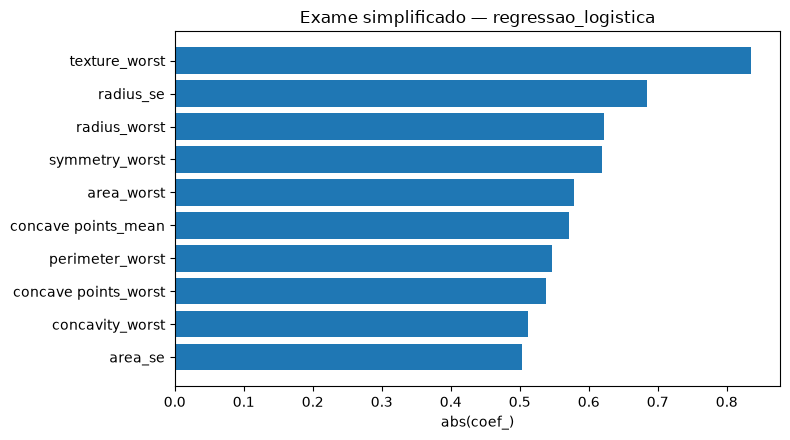

In [6]:
modelos_logistica = {
    "Otimizado (GA)": (modelo_log_otimizado, melhor_log, metricas_log_otimizado),
    "Mutação adaptativa": (modelo_log_adaptativo, melhor_log_adaptativo, metricas_log_adaptativo),
    "Mutação adaptativa + seleção por roleta": (modelo_log_adaptativo_roleta, melhor_log_adaptativo_roleta, metricas_log_adaptativo_roleta),
}

melhor_versao = max(modelos_logistica, key=lambda v: (modelos_logistica[v][2]["recall"], modelos_logistica[v][2]["f1"]))
modelo_vencedor, hiper_vencedor, metricas_vencedor = modelos_logistica[melhor_versao]
melhor_algoritmo = "regressao_logistica"
print(f"Melhor versão da Regressão Logística (maior recall, desempate por F1): {melhor_versao}")

metodo_i, ranking_i = ga_utils.importancias_do_modelo(modelo_vencedor, feature_names)
print(f"Importância das medidas — {melhor_versao} ({metodo_i}):\n")
for item in ranking_i[:5]:
    print(f"  {item['feature']:24} {item['importancia']:.4f}")
print()

exame_simplificado = ga_utils.persistir_exame_simplificado(
    algoritmo=melhor_algoritmo,
    modelo=modelo_vencedor,
    hiperparametros=hiper_vencedor,
    feature_names=feature_names,
)

print("10 medidas exportadas para a API e o Angular:")
for i, item in enumerate(exame_simplificado["features"], start=1):
    print(f"  {i:2}. {item['feature']:24} {item['importancia']:.4f}")
print("\nMétricas do exame simplificado no holdout:", exame_simplificado["metricas_holdout"])
print("Arquivo:", RESULTADOS_DIR / "feature_importances.json")

nomes = [item["feature"] for item in exame_simplificado["features"]][::-1]
pesos = [item["importancia"] for item in exame_simplificado["features"]][::-1]
plt.figure(figsize=(8, 4.5))
plt.barh(nomes, pesos)
plt.xlabel(exame_simplificado["metodo"])
plt.title(f"Exame simplificado — {exame_simplificado['algoritmo']}")
plt.tight_layout()
plt.show()

## Interpretação com LLM (Claude)

Até aqui o notebook está cheio de número: acurácia, recall, `area_worst`, probabilidade... Isso é ótimo pra gente comparar modelo, mas um médico não vai ler a tabela e sair entendendo o exame.

A ideia desta parte é simples: a gente pega o que o modelo já calculou e pede pro Claude escrever em português, como se fosse um colega explicando o resultado. Não é o Claude que diagnostica — ele só traduz o que o modelo já decidiu.

Mandamos dois pedidos:

1. **Laudo de um paciente** — o mesmo tipo de texto que a API e o front mostram: deu positivo ou negativo, qual a chance de ser maligno e por quê (tamanho, textura, formato).
2. **Relatório dos experimentos** — um resumo de qual modelo ganhou depois do GA e quais medidas do tumor mais pesaram.

O texto que a gente “ensina” o Claude a seguir (o prompt) está em `src/llm_utils.py`. Separar o papel dele dos números do paciente evita que ele invente exame ou fale em hiperparâmetro no laudo.

Para esta célula funcionar, a chave da Anthropic precisa estar no arquivo `.env`.

In [7]:
modelo_final, hiperparametros_final, metricas_final = modelo_vencedor, hiper_vencedor, metricas_vencedor
y_pred_final = ga_utils.prever_modelo(melhor_algoritmo, modelo_final, X_test, hiperparametros_final)

idx = next((i for i in range(len(y_pred_final)) if int(y_pred_final[i]) == 1), 0)
predicao_texto = "Maligno" if int(y_pred_final[idx]) == 1 else "Benigno"
if hasattr(modelo_final, "predict_proba"):
    chance_doenca = float(modelo_final.predict_proba(X_test[idx : idx + 1])[0][1])
else:
    chance_doenca = float(np.clip(modelo_final.predict(X_test[idx : idx + 1])[0], 0, 1))

valores_originais = scaler.inverse_transform(X_test[idx : idx + 1])[0]
features_paciente = llm_utils.obter_features_importantes(
    modelo_final, feature_names, valores_originais
)
prompt_laudo = llm_utils.montar_prompt(
    predicao=predicao_texto,
    chance_doenca=chance_doenca,
    features_importantes=features_paciente,
    accuracy=metricas_final["accuracy"],
    recall=metricas_final["recall"],
    f1=metricas_final["f1"],
    contexto_ga=llm_utils.formatar_contexto_ga(melhor_algoritmo, hiperparametros_final),
)
prompt_relatorio = llm_utils.montar_prompt_relatorio(
    comparacao=comparacao_final,
    melhor_algoritmo=melhor_algoritmo,
    hiperparametros=hiperparametros_final,
    metricas=metricas_final,
    features_top=exame_simplificado["features"],
)

chave = llm_utils.carregar_chave_do_env()
if not chave:
    print("Preencha ANTHROPIC_API_KEY no .env na raiz do projeto para o Claude escrever os textos.")
else:
    laudo = llm_utils.gerar_explicacao(prompt_laudo, api_key=chave)
    relatorio = llm_utils.gerar_explicacao(
        prompt_relatorio,
        api_key=chave,
        system_prompt=llm_utils.SYSTEM_PROMPT_RELATORIO,
        max_tokens=700,
    )
    print("=== Laudo de um paciente (mesmo tipo da API) ===\n")
    print(laudo)
    print("\n=== Relatório dos experimentos do GA ===\n")
    print(relatorio)
    (RESULTADOS_DIR / "relatorio_llm.txt").write_text(
        "LAUDO\n\n" + laudo + "\n\nRELATÓRIO\n\n" + relatorio,
        encoding="utf-8",
    )


=== Laudo de um paciente (mesmo tipo da API) ===

**LAUDO DE TRIAGEM AUTOMÁTICA DE CÂNCER DE MAMA**

**Resultado: POSITIVO — Tumor classificado como MALIGNO**

A triagem automática indicou **100% de chance de o tumor ser maligno**. A detecção se baseou principalmente em três características preocupantes: a textura extremamente alterada do nódulo, o tamanho bastante aumentado e uma variação irregular no raio que sugere bordas não uniformes. Esses achados em conjunto levantam sinal de alerta para malignidade.

É importante ressaltar que este é um resultado de triagem automática e **não substitui o diagnóstico clínico e a avaliação de um especialista**. Recomenda-se prosseguir com investigação diagnóstica complementar urgente, incluindo análise clínica detalhada e confirmação anatomopatológica.

=== Relatório dos experimentos do GA ===

# Relatório do Experimento de Triagem de Câncer de Mama

O modelo otimizado com Regressão Logística apresentou o melhor desempenho, alcançando acurácia de

## Avaliação das interpretações

Não tem uma nota automática do tipo “o laudo tirou 9,2”. A gente lê o que o Claude escreveu e vê se está honesto e útil.

No laudo: ele começou dizendo se deu positivo ou negativo? A porcentagem é a mesma que o modelo calculou? Ele fala do tumor (tamanho, textura, contorno) sem inventar outro exame? No final ele deixa claro que isso é uma triagem, não um diagnóstico médico?

No relatório: ele aponta o mesmo vencedor da tabela de cima? As medidas que ele cita são as que exportamos no exame simplificado?

Se alguma coisa escapar — um número inventado, um termo de machine learning no meio do laudo — o problema quase sempre está no que a gente pediu, em `src/llm_utils.py`. Aí a gente ajusta o prompt e roda de novo.

## Conclusão

- Os 3 algoritmos do notebook 01 foram otimizados via Algoritmo Genético, cada um com um espaço de genes adequado ao seu tipo de hiperparâmetro.
- 5 experimentos ao todo: 3 com configurações diferentes do GA (população/mutação/gerações), um por algoritmo (Experimentos 1–3); mais 2 isolando a troca de um único operador — seleção por roleta no Random Forest (Experimento 4, vs. torneio no Experimento 3) e mutação adaptativa na Regressão Logística (Experimento 5, vs. taxa fixa no Experimento 2).
- A tabela de comparação (`experiments/results/comparison_table.csv`) mostra o ganho (ou não) de cada modelo otimizado em relação ao baseline, considerando os Experimentos 1–3.
- Os Experimentos 4 e 5 não entram na escolha do modelo de produção nem na exportação de `feature_importances.json` — servem só pra comparar operadores do GA entre si.
- As feature importances do vencedor (entre os Experimentos 1–3) vão para `feature_importances.json`; a API e o Angular montam o exame simplificado a partir desse arquivo.
- A LLM gera um laudo de paciente (igual à API) e um relatório dos experimentos. Os prompts estão em `src/llm_utils.py`.
